In [1]:
import pandas as pd
import numpy as np

# Create a dataset — imagine this is test results from your QA work
data = {
    "test_name": ["login_flow", "checkout", "search", "profile", "api_auth"],
    "pass_rate": [0.98, 0.91, 0.87, 0.99, 0.76],
    "run_time_ms": [120, 340, 89, 210, 450],
    "flaky": [False, True, False, False, True]
}

df = pd.DataFrame(data)
df

,test_name,pass_rate,run_time_ms,flaky
0,login_flow,0.98,120,False
1,checkout,0.91,340,True
2,search,0.87,89,False
3,profile,0.99,210,False
4,api_auth,0.76,450,True


In [2]:
# Basic stats on your test data
print(df.describe())

# Filter: only flaky tests
flaky_tests = df[df["flaky"] == True]
print("\nFlaky tests:")
print(flaky_tests)

       pass_rate  run_time_ms
count   5.000000     5.000000
mean    0.902000   241.800000
std     0.093648   151.809749
min     0.760000    89.000000
25%     0.870000   120.000000
50%     0.910000   210.000000
75%     0.980000   340.000000
max     0.990000   450.000000

Flaky tests:
  test_name  pass_rate  run_time_ms  flaky
1  checkout       0.91          340   True
4  api_auth       0.76          450   True


Matplotlib is building the font cache; this may take a moment.


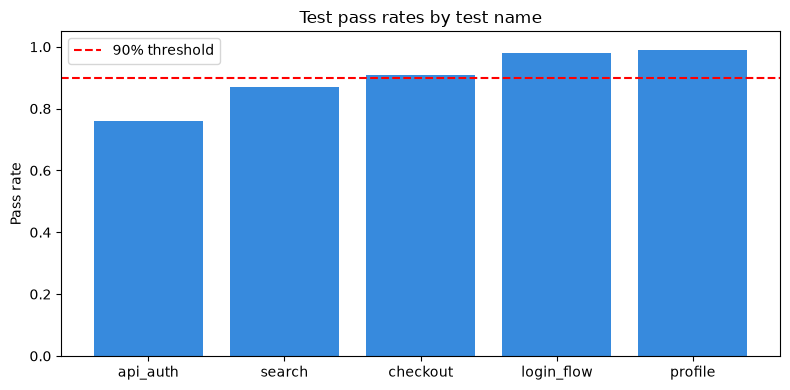

In [3]:
import matplotlib.pyplot as plt

# Bar chart of pass rates — worst performers first
df_sorted = df.sort_values("pass_rate", ascending=True)

plt.figure(figsize=(8, 4))
plt.bar(df_sorted["test_name"], df_sorted["pass_rate"], color="#378ADD")
plt.axhline(y=0.90, color="red", linestyle="--", label="90% threshold")
plt.ylim(0, 1.05)
plt.ylabel("Pass rate")
plt.title("Test pass rates by test name")
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# Sort by pass rate — worst first
df_sorted = df.sort_values("pass_rate", ascending=True)
print("Tests ranked by pass rate:")
print(df_sorted[["test_name", "pass_rate"]])

# Build a lookup dict — test name → pass rate
# This pattern shows up everywhere in RAG pipelines
lookup = {row["test_name"]: row["pass_rate"] for _, row in df.iterrows()}
print("\nLookup dict:")
print(lookup)

# Find tests below threshold
failing = {name: rate for name, rate in lookup.items() if rate < 0.90}
print("\nTests below 90%:")
print(failing)

Tests ranked by pass rate:
    test_name  pass_rate
4    api_auth       0.76
2      search       0.87
1    checkout       0.91
0  login_flow       0.98
3     profile       0.99

Lookup dict:
{'login_flow': 0.98, 'checkout': 0.91, 'search': 0.87, 'profile': 0.99, 'api_auth': 0.76}

Tests below 90%:
{'search': 0.87, 'api_auth': 0.76}
